In [ ]:
import sys
origin = '/workspace/'
sys.path.append('/media/')

from tqdm import tqdm
from FieldWaterUseTools.FuncBox.Misc import path_safe, dirfinder, get_row_col_indices, checkPath, getFilelist,\
     stackReader, warp_np_to_reference
from FieldWaterUseTools.FuncBox.FieldFuncis import *
from FieldWaterUseTools.FuncBox.DICT_LIST import VALID_AGRO_VALUES


####################################################### Prepare
states = ['Brandenburg', 'Niedersachsen', 'MV', 'NRW', 'Saarland']
state_folders = ['BRB', 'LSA', 'MV', 'NRW', 'SL']
model_names = ['model_state_FromScratch_IACS_dilate_False_BorderEdgeCutted_RGB_NDVI_exclude_True_with_overlap_22',
               'model_state_IACS_dilate_False_BorderEdgeCutted_RGB_NDVI_exclude_True_with_overlap_40_on_AI4_RGB_exclude_True_38_FREEZER_2',
               'model_state_IACS_dilate_True_BorderEdgeCutted_RGB_NDVI_exclude_True_with_overlap_40_on_AI4_RGB_exclude_True_38_FREEZER_2'] #'model_state_AI4_RGB_exclude_True_38'


for model_name in model_names:

     year = 2023
     state = 'Brandenburg'
     # set tiling scheme and chip size on which prediction will be undertaken
     chipsize = 128*2 # 5 or 6 is the maximum with GPU in basement
     overlap  = 20

     # set paths
     state_code = state_folders[states.index(state)]
     predict_master_folder = path_safe(f"{origin}fields/04_Predictions/{state}/{model_name.split('_state_')[-1]}/{year}/")
     vrt_path = f"{origin}fields/Misc/S2vrt/{state_code}/{year}/"
     vrt_Folder = f"{vrt_path}{dirfinder(vrt_path)[0]}"

     


/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47
/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47
/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47


In [2]:
vrtFiles = [file for file in getFilelist(vrt_Folder, '.vrt') if 'Cube' not in file]
vrtFiles = sortListwithOtherlist([int(vrt.split('_')[-1].split('.')[0]) for vrt in vrtFiles], vrtFiles)[-1]
bands = []

In [3]:
vrtFiles

['/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_0.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_1.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_2.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_3.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_4.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_5.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_6.vrt',
 '/workspace/fields/Misc/S2vrt/BRB/2023/Force_X_from_64_to_73_Y_from_39_to_47/Force_X_from_64_to_73_Y_from_39_to_47_7.vrt',
 '/works

In [1]:
import math
import time
from osgeo import gdal
import numpy as np
import pandas as pd
from skimage import measure
from joblib import Parallel, delayed
import os
import sys

origin = '/workspace/'
sys.path.append('/media/')

from FieldWaterUseTools.FuncBox.Misc import getFilelist, path_safe, makeTif_np_to_matching_tif, export_intermediate_products, makePyramidsForTif, stackReader
from FieldWaterUseTools.FuncBox.FieldFuncis import get_IoUs_per_Tile, subset_mask_to_prediction_extent
from FieldWaterUseTools.FuncBox.DICT_LIST import VALID_AGRO_VALUES

In [2]:
states = ['Brandenburg', 'Niedersachsen', 'MV', 'NRW', 'Saarland']
state_folders = ['BRB', 'LSA', 'MV', 'NRW', 'SL']


# set variables
year = 2023
model_name = 'AI4_RGB_exclude_True_38'
state = 'Brandenburg'
state_code = state_folders[states.index(state)]
ncores = 28
np.random.seed(42)
slicer = 10 # determines the number of tiles whole prediction will be be sliced into
border_limit = 5 # dont sample fields too close to tile borders
sample_size  = 20000
make_tifs_from_intermediate_step = False # for debugging and checks

# paths
thuenen_path = [file for file in getFilelist(f"{origin}et/Auxiliary/landcover/thuenen/", '.tif') if str(year) in file][0]
path_to_predictions = f"{origin}fields/04_Predictions/{state}/{model_name}/{year}/vrt/" # at this location, there are 
# all vrts with different chipsizes and overlaps, as well as thuenenmasked and unmasked
path_to_IACS = f"{origin}fields/01_IACS/4_Crop_mask/{state_code}/{year}/IACS_{state_code}_{year}_cropMask_cropMask_lines_touch_false_crop_touch_false_linecrop.tif" 
# all versions of the masks
# no good choices: all masks that are not linecropped 
# - cropMask_lines_touch_false_crop_touch_true --> makes fields too large
# - cropMask_lines_touch_true_crop_touch_true --> makes fields too large, no borders between close fields
# - cropMask_cropMask_lines_touch_false_crop_touch_false --> makes fields too large
# - cropMask_cropMask_lines_touch_true_crop_touch_false --> makes fields too large
# from the ones that were linecropped: 
# - cropMask_cropMask_lines_touch_false_crop_touch_false_linecrop: closest match
# - cropMask_lines_touch_false_crop_touch_true_linecrop --> 2nd best choice
# - cropMask_lines_touch_true_crop_touch_true_linecrop --> contains artefacts: fields where there are none
# - cropMask_cropMask_lines_touch_true_crop_touch_false_linecrop --> similar to cropMask_cropMask_lines_touch_false_crop_touch_false_linecrop, but less overlap

chip_overlap_mask_combos = ['ThuenenMask_768_20']
pred_list = [f"{path_to_predictions}{combi}.vrt" for combi in chip_overlap_mask_combos]

overlords_jobs = []

ref_dim = 0

for idx, prediction in enumerate(pred_list):
    if idx == 0:
        intermediate_export = True
    else:
        intermediate_export = False
    reference_arr = subset_mask_to_prediction_extent(path_to_IACS, prediction, returnToMemory=True)

    if 'ThuenenMask' in prediction:
        thuenen_arr = subset_mask_to_prediction_extent(thuenen_path, prediction, returnToMemory=True)
        th_mask = np.isin(thuenen_arr, VALID_AGRO_VALUES).astype(np.uint8)
        reference_arr[th_mask == 0] = 0 # important when we test against the thuenen masked prediction
    outFolder = path_safe(f"{origin}fields/05_GridSearch/{state}/{model_name}/{year}/{chip_overlap_mask_combos[idx]}/")

    inter_path = path_safe(f'{outFolder}intermediates/')
    result_path = path_safe(f'{outFolder}results/')

    ######### prepare job-list

    # create lists that will be passed on to the joblist
    # tile_list = []
    extent_true_list = []
    extent_pred_list = []
    boundary_pred_list = []
    result_dir_list = []
    row_col_start = []

    # tile predictions in prds --> total extent encompasses 90 Force Tiles (+ a few rows and cols that will be neglected as they are outside of study area)
    pred_ds = gdal.Open(prediction)

    if reference_arr.shape != ref_dim:

        rows, cols = pred_ds.RasterYSize, pred_ds.RasterXSize

        row_start = [i for i in range(0, rows, math.floor(rows/slicer))]
        row_end = [i for i in range (math.floor(rows/slicer), rows, math.floor(rows/slicer))]
        row_start = row_start[:len(row_end)] 

        col_start = [i for i in range(0, cols, math.floor(cols/slicer))]
        col_end = [i for i in range (math.floor(cols/slicer), cols, math.floor(cols/slicer))]
        col_start = col_start[:len(col_end)] 

        # label IACS reference mask
        binary_true = reference_arr > 0 # extent_true
        instances_true = measure.label(binary_true, background=0, connectivity=1)

        if make_tifs_from_intermediate_step:
            makeTif_np_to_matching_tif(instances_true, prediction, f"{inter_path}instances_true.tif", 0)
            makePyramidsForTif(f"{inter_path}instances_true.tif")
        
        # sample fields
        # build a mask to exclude fields that are in border_limit to tile borders
        power_mask = np.zeros(instances_true.shape)
        for i in range(len(row_end)):
            for j in range(len(col_end)):
                    power_mask[row_start[i]:row_start[i] + border_limit, :] = 1
                    power_mask[:, col_start[j]:col_start[j] + border_limit] = 1
                    power_mask[row_end[-1] - border_limit:power_mask.shape[0], :] = 1
                    power_mask[:, col_end[-1] - border_limit:power_mask.shape[1]] = 1

        if make_tifs_from_intermediate_step:
            makeTif_np_to_matching_tif(power_mask, prediction, f"{inter_path}powermask.tif", 0)
            makePyramidsForTif(f"{inter_path}powermask.tif")


    if reference_arr.shape != ref_dim:
        # get distribution of field sizes after segmentation
        unique_IDs, counts = np.unique(instances_true, return_counts=True)

        # get IDs from labelled reference that wil lbe excluded
        IDs_to_skip = np.unique(instances_true[power_mask==1])

        # exlcude fields that are too close to tile borders
        mask = ~np.isin(unique_IDs, IDs_to_skip)
        unique_IDs = unique_IDs[mask]
        counts = counts[mask]

        if make_tifs_from_intermediate_step:
            # Create filtered array with only valid IDs preserved for export
            filtered_instances = np.where(np.isin(instances_true, unique_IDs), instances_true, 0)
            makeTif_np_to_matching_tif(filtered_instances, prediction, f"{inter_path}chips_border_cut.tif", 0, gdalType=gdal.GDT_UInt32)
            makePyramidsForTif(f"{inter_path}chips_border_cut.tif")

    if reference_arr.shape != ref_dim:
        pixelthresh = 5
        deciles = [perc for perc in range(10,100,10)]
        mask = (unique_IDs != 0)  & (counts > pixelthresh)
        unique_IDs = unique_IDs[mask]
        counts = counts[mask]

        # get deciles and draw equally from them

        deciles_values = np.percentile(counts, deciles)
        decs = [0] + deciles_values.tolist() + [np.max(counts)]

        # exlude 0 (background) and 1 (super-small fields) from sample
        pixelthresh = 5
        deciles = [perc for perc in range(10,100,10)]
        while True:
            mask = (unique_IDs != 0)  & (counts > pixelthresh)
            unique_IDs = unique_IDs[mask]
            counts = counts[mask]

            # draw equally from decile ranges
            deciles_values = np.percentile(counts, deciles)
            decs = [0] + deciles_values.tolist() + [np.max(counts)]

            if len(decs) == len(set(decs)): # accounts for larger amount of small fields, where the deciles are the same
                df = pd.DataFrame({'decile_value': decs,
                        'excluded_pixel':pixelthresh})
                df.to_csv(f"{inter_path}decs_output.csv", index=False)
                break
            else:
                pixelthresh += 1

        bin_ids = []
        for ind in range(len(decs) -1):
            # get the unique_IDS of those fields, whose count (size) is within bin
            bin_ids.append(np.random.choice(unique_IDs[(counts > decs[ind]) & (counts <= decs[ind + 1])], int(sample_size/10), replace=False))

        instances_true = np.where(np.isin(instances_true, np.concatenate(bin_ids)),
                                instances_true,
                                0)

        if make_tifs_from_intermediate_step:
            # Create filtered array with only valid IDs preserved for export
            filtered_instances = np.where(np.isin(instances_true, unique_IDs), instances_true, 0)
            makeTif_np_to_matching_tif(filtered_instances, prediction, f"{inter_path}sampled_IDs.tif", 0, gdalType=gdal.GDT_UInt32)
            makePyramidsForTif(f"{inter_path}sampled_IDs.tif")

    ref_dim = reference_arr.shape 

    print('IDs selected - start tiling')

    # read in vrt in tiles
    for i in range(len(row_end)):
        for j in range(len(col_end)):
            
            # check for the file in result folder
            row_col_identifier = str(row_start[i]) + '_' + str(col_start[j])
            if os.path.isfile(f"{result_path}{row_col_identifier}_IoU_hyperparameter_tuning.csv"):
                continue
            ######### fill the lists with tiled data
        
            # check if tile contains a sample of reference/label data
            extent_true_label = instances_true[row_start[i]:row_end[i], col_start[j]:col_end[j]]
            if len(np.unique(extent_true_label)) == 1:
                continue
            
            extent_true_list.append(extent_true_label)
            
            #subset the prediction of fields read-in
            extent_pred_list.append(pred_ds.GetRasterBand(1).ReadAsArray(\
                col_start[j], row_start[i], col_end[j] - col_start[j], row_end[i] - row_start[i]))
                # goes into InstSegm --> image of crop probability 
            
            # load predicted boundary prob subset // goes into InstSegm --> image of boundary probability
            boundary_pred_list.append(pred_ds.GetRasterBand(2).ReadAsArray(col_start[j], row_start[i], col_end[j] - col_start[j], row_end[i] - row_start[i])) 
            
            # output folder
            result_dir_list.append(result_path)
            row_col_start.append(row_col_identifier)

            # double check
            if make_tifs_from_intermediate_step:
                export_intermediate_products(row_col_identifier, extent_pred_list[-1],\
                            pred_ds.GetGeoTransform(), pred_ds.GetProjection(), inter_path, \
                                filename='extend_pred_' + row_col_identifier + '.tif', noData=0, typ='float')

    jobs = [[row_col_start[i] ,extent_true_list[i], extent_pred_list[i], boundary_pred_list[i], result_dir_list[i], \
                pred_ds.GetGeoTransform(), pred_ds.GetProjection(), inter_path, intermediate_export]  for i in range(len(result_dir_list))]

    print(f'\n{len(jobs)} tiles will be processed\n')

    del row_col_start, extent_true_list, extent_pred_list, boundary_pred_list, result_dir_list

    overlords_jobs.append(jobs)


IDs selected - start tiling

4 tiles will be processed



In [7]:
job = overlords_jobs[0][1]

row_col_start = job[0]
extent_true = job[1]
extent_pred = job[2]
boundary_pred = job[3]
result_dir = job[4]
dummy_gt = job[5]
dummy_proj = job[6]
intermediate_path = job[7]
intermediate=False
t_ext=False
t_bound=False
    
print(f'Starting on tile {row_col_start} for {result_dir}')
# make a dictionary for export
k = ['row_col_start','t_ext','t_bound', 'max_IoU', 'centroid_IoU', 'centroid_row', 'centroid_col', 'centroid_IDs',\
        'reference_field_IDs', 'reference_field_sizes', 'intersect_IDs', 'ratio_intersect_area_pred', 'ratio_intersect_area_true'] #'medianIoU', 'meanIoU', 'IoU_50', 'IoU_80']
v = [list() for i in range(len(k))]
res = dict(zip(k, v))

# set the parameter combinations and test combinations
if not t_ext:
    t_exts = [i/100 for i in range(10,95,5)] 
    t_bounds = [i/100 for i in range(10,95,5)]
else:
    if isinstance(t_ext, list):
        t_exts = t_ext
        t_bounds = t_bound
    else:
        t_exts = [t_ext]
        t_bounds = [t_bound]
# loop over parameter combinations
t_ext = 0.80
t_bound = 0.3
row_col_start = row_col_start
extent_true = extent_true
extent_pred = extent_pred
boundary_pred = boundary_pred
t_ext = t_ext
t_bound = t_bound
dummy_gt = dummy_gt
dummy_proj = dummy_proj
intermediate_path = intermediate_path
intermediate = intermediate

Starting on tile 18830_20979 for /workspace/fields/05_GridSearch/Brandenburg/AI4_RGB_exclude_True_38/2023/ThuenenMask_256_20/results/


In [8]:
# get predicted instance segmentation
instances_pred = InstSegm(extent_pred, boundary_pred, t_ext=t_ext, t_bound=t_bound)
instances_pred = measure.label(instances_pred, background=-1) 


# get instances from ground truth label; already done globally during joblist creation
instances_true = extent_true


# create all lists to collect values
best_IoUs = []
field_IDs = [] # the ID given from global labelling to sampled reference IACS polyon
field_sizes = [] # the number of pixel of the reference IACS field (field_IDs)
ratio_field_overlap_pred = [] # this is the ratio of the intersection between reference and prediction polygon and the entire predicted polygon with the best IoU score for the respective reference polygon (field_IDs)
ratio_field_overlap_true = [] # this is the ratio of the intersection between reference and prediction polygon and the entire reference polygon with the best IoU score for the respective reference polygon (field_IDs)
centroid_rows = [] # the row an IACS reference polygon at the same index as at field_IDs
centroid_cols = [] # the col an IACS reference polygon at the same index as at field_IDs
centroid_IoUS = [] # the IoU of the predicted polygon that covers the centroid of respective reference polygon (field_ID)
centroid_IDs = [] # gives the ID from labelling at instances_pred from the predicted polygon that covers the centroid of respective reference polygon (field_ID)
intersect_IDs  = [] # gives the ID from labelling at instances_pred from the predicted polygon with the best IoU for the field_ID at the respective index

# loop over sampled true (reference) fields
field_values = np.unique(instances_true)

In [124]:
field_value = field_values[150]
this_field = instances_true == field_value # makes a binary raster for the respective sampled IACS poylgon
this_field_centroid = np.mean(np.column_stack(np.where(this_field)),axis=0).astype(int) # calculates the centroid of that polygon

centroid_rows.append(this_field_centroid[0])
centroid_cols.append(this_field_centroid[1])
field_IDs.append(field_value)
field_sizes.append(np.sum(this_field))

# find predicted fields that intersect with true field
intersecting_fields = this_field * instances_pred # multiplies binary raster of sampled IACS poylgon with prediction --> only overlapping predicted fields in raster
intersect_values = np.unique(intersecting_fields) # get the labeled IDS from intersecting predicted fields

# compute IoU for each intersecting field and then store the best one in list outside of this loop
field_IoUs = [] # stores the IoUs off all intersecting polygons
intersect_area_pred = [] # this is the ratio of the intersection between reference and prediction polygon and the entire predicted polygon
intersect_area_true = []# this is the ratio of the intersection between reference and prediction polygon and the entire reference polygon
centroid_IoU = 0
centroid_ID = 0

In [127]:
pred_ids, pred_areas = np.unique(intersecting_fields, return_counts=True)
if 0 in pred_ids:
    id0 = np.where(pred_ids == 0)
    pred_areas = np.delete(pred_areas, id0)
    pred_ids = np.delete(pred_ids, id0)

    if pred_ids.size == 0:
        field_IoUs.append(0)
        intersect_area_pred.append(0)
        intersect_area_true.append(0)
        best_IoUs.append(0)
        ratio_field_overlap_pred.append(0)
        ratio_field_overlap_true.append(0)
        intersect_IDs.append(0)
        centroid_IoUS.append(centroid_IoU)
        centroid_IDs.append(centroid_ID)
    else:
        pass



In [144]:
np.unique(this_field + intersecting_fields2)

array([   0,    1,  501, 1227])

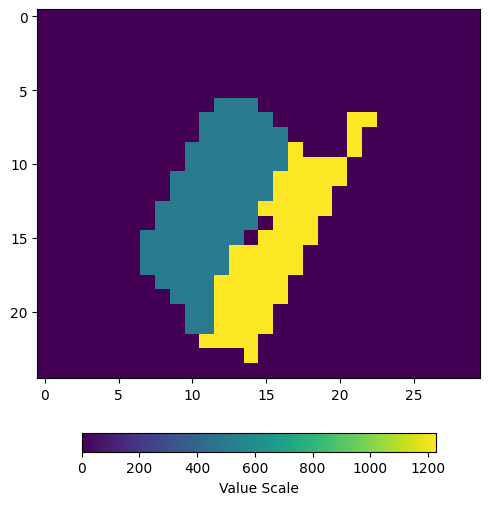

In [138]:
from helperToolz.helpsters import plotter

intersecting_fields2 = np.where(intersecting_fields == 1222,500, intersecting_fields)
plotter(intersecting_fields2[725:750,375:405])

In [ ]:
for intersect_value in intersect_values: # loop over all predicted polygons that intersect with the referene IACS polygon
    if intersect_value == 0: # this is just the masked background, not an actual polygon
        field_IoUs.append(0)
        intersect_area_pred.append(0)
        intersect_area_true.append(0)
        continue # move on to next value
    
    pred_field = instances_pred == intersect_value # makes a binary raster of of intersecting predicted field
    pred_field_area = np.sum(pred_field) # calculates the area of that polygon

    # calculate IoU
    union = (this_field + pred_field) > 0 # this is the union area of the reference and predicted polygon (--> the U in IoU)
    intersection = (this_field * pred_field) > 0 # this the intersect area of the reference and predicted polygon (--> the I in IoU)
    IoU = np.sum(intersection) / np.sum(union) # (--> the o in IoU)
    field_IoUs.append(IoU)
    intersect_area_pred.append(np.sum(intersection) / pred_field_area)
    intersect_area_true.append(np.sum(intersection) / np.sum(this_field))

    # check for centroid condition
    if instances_pred[this_field_centroid[0], this_field_centroid[1]] == intersect_value:
        centroid_IoU = IoU
        centroid_ID = intersect_value

# take maximum IoU - this is the IoU for this true field
if len(field_IoUs) > 1 or field_IoUs[0] != 0: # if there is only one value that is not 0, the condition is True
    best_IoUs.append(np.max(field_IoUs))
    ratio_field_overlap_pred.append(intersect_area_pred[np.argmax(field_IoUs)])
    ratio_field_overlap_true.append(intersect_area_true[np.argmax(field_IoUs)])
    intersect_IDs.append(intersect_values[np.argmax(field_IoUs)]) # works because the is a value in field_IoUs for every intersect_value
else:
    best_IoUs.append(0)
    ratio_field_overlap_pred.append(0)
    ratio_field_overlap_true.append(0)
    intersect_IDs.append(0)

# fill centroid list
centroid_IoUS.append(centroid_IoU)
centroid_IDs.append(centroid_ID)

[0]


In [ ]:
for field_value in field_values:

    this_field = instances_true == field_value # makes a binary raster for the respective sampled IACS poylgon
    this_field_centroid = np.mean(np.column_stack(np.where(this_field)),axis=0).astype(int) # calculates the centroid of that polygon

    centroid_rows.append(this_field_centroid[0])
    centroid_cols.append(this_field_centroid[1])
    field_IDs.append(field_value)
    field_sizes.append(np.sum(this_field))

    # find predicted fields that intersect with true field
    intersecting_fields = this_field * instances_pred # multiplies binary raster of sampled IACS poylgon with prediction --> only overlapping predicted fields in raster
    intersect_values = np.unique(intersecting_fields) # get the labeled IDS from intersecting predicted fields

    # compute IoU for each intersecting field and then store the best one in list outside of this loop
    field_IoUs = [] # stores the IoUs off all intersecting polygons
    intersect_area_pred = [] # this is the ratio of the intersection between reference and prediction polygon and the entire predicted polygon
    intersect_area_true = []# this is the ratio of the intersection between reference and prediction polygon and the entire reference polygon
    centroid_IoU = 0
    centroid_ID = 0
